In [1]:
# Installation (falls nötig)
%pip -q install numpy pandas scipy scikit-learn torch matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports, Seed und Device
import os, re, random, pathlib, math
from typing import List, Optional, Dict
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_rel

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
# Datenpfade
base_dir = r"C:\Users\tamin\Documents\Masterarbeit 2025\Implementierung Algortihmen\archive\Schizophrenia"
norm_dir = os.path.join(base_dir, "norm")
sch_dir  = os.path.join(base_dir, "sch")

# Fallback auf "Schiziphrenia", falls der Ordner so heißt
if not (os.path.isdir(norm_dir) and os.path.isdir(sch_dir)):
    alt_base = os.path.join(os.path.dirname(base_dir), "Schiziphrenia")
    alt_norm = os.path.join(alt_base, "norm")
    alt_sch  = os.path.join(alt_base, "sch")
    if os.path.isdir(alt_norm) and os.path.isdir(alt_sch):
        base_dir, norm_dir, sch_dir = alt_base, alt_norm, alt_sch

def list_eea_files(folder: str) -> List[str]:
    if not os.path.isdir(folder):
        return []
    return sorted([str(p) for p in pathlib.Path(folder).glob("*.eea")])

norm_files = list_eea_files(norm_dir)
sch_files  = list_eea_files(sch_dir)
file_paths = norm_files + sch_files
file_labels = np.array([0]*len(norm_files) + [1]*len(sch_files))

print("Basisverzeichnis:", base_dir)
print(f"Gefundene norm-Dateien: {len(norm_files)}")
print(f"Gefundene sch-Dateien:  {len(sch_files)}")
assert len(file_paths) > 0, "Keine .eea-Dateien gefunden!"

Basisverzeichnis: C:\Users\tamin\Documents\Masterarbeit 2025\Implementierung Algortihmen\archive\Schizophrenia
Gefundene norm-Dateien: 39
Gefundene sch-Dateien:  45


In [4]:
# EEA-Loader (robust) – ohne FutureWarning
_num_regex = re.compile(r"[-+]?(?:\d+(?:[.,]\d+)?|\.\d+)")

def try_read_csv_like(path: str) -> np.ndarray:
    df = pd.read_csv(
        path,
        sep=r"[,\t; ]+",
        engine="python",
        comment="#",
        header=None,
        dtype=str,
        skip_blank_lines=True
    )
    df = df.dropna(axis=1, how="all")
    df = df.map(lambda x: x.replace(",", ".") if isinstance(x, str) else x)
    vals = df.astype(float).values
    if vals.ndim == 1:
        vals = vals[:, None]
    return vals

def try_read_regex(path: str) -> np.ndarray:
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            nums = _num_regex.findall(line)
            if not nums:
                continue
            nums = [n.replace(",", ".") for n in nums]
            try:
                row = [float(n) for n in nums]
            except Exception:
                continue
            rows.append(row)
    if not rows:
        raise ValueError("No numeric rows parsed")
    max_len = max(len(r) for r in rows)
    rows = [r + [np.nan]*(max_len - len(r)) for r in rows]
    arr = np.array(rows, dtype=float)
    keep = ~np.all(np.isnan(arr), axis=0)
    arr = arr[:, keep]
    if np.any(np.isnan(arr)):
        col_med = np.nanmedian(arr, axis=0)
        inds = np.where(np.isnan(arr))
        arr[inds] = np.take(col_med, inds[1])
    if arr.ndim == 1:
        arr = arr[:, None]
    return arr

def load_eea_file(path: str) -> np.ndarray:
    try:
        return try_read_csv_like(path)
    except Exception:
        return try_read_regex(path)

In [5]:
# Fensterung, Subsampling, Skalierung
def segment_windows(arr: np.ndarray, window_size: int, step_size: int) -> np.ndarray:
    if arr.ndim == 1:
        arr = arr[:, None]
    T, C = arr.shape
    if T < window_size:
        pad = np.zeros((window_size, C), dtype=arr.dtype)
        pad[:T] = arr
        return pad[None, ...]
    starts = range(0, T - window_size + 1, step_size)
    windows = [arr[s:s+window_size, :] for s in starts]
    return np.stack(windows, axis=0) if windows else arr[None, :window_size, :]

def build_windows_for_files(paths: List[str], labels: np.ndarray, window_size: int, step_size: int):
    X_list, y_list, file_idx = [], [], []
    for i, p in enumerate(paths):
        arr = load_eea_file(p)
        Xw = segment_windows(arr, window_size, step_size)
        yw = np.full((Xw.shape[0],), labels[i], dtype=int)
        X_list.append(Xw)
        y_list.append(yw)
        file_idx.extend([i]*Xw.shape[0])
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    file_idx = np.array(file_idx)
    return X, y, file_idx

def subsample_per_file(X, y, file_idx, max_per_file: Optional[int], seed=SEED):
    if (max_per_file is None) or (max_per_file <= 0):
        return X, y, file_idx
    rng = np.random.default_rng(seed)
    keep = []
    for fid in np.unique(file_idx):
        idx = np.where(file_idx == fid)[0]
        if len(idx) > max_per_file:
            idx = rng.choice(idx, size=max_per_file, replace=False)
        keep.append(idx)
    keep = np.concatenate(keep)
    keep.sort()
    return X[keep], y[keep], file_idx[keep]

def fit_scaler_per_channel(X: np.ndarray) -> StandardScaler:
    N, T, C = X.shape
    scaler = StandardScaler()
    scaler.fit(X.reshape(N*T, C))
    return scaler

def apply_scaler(X: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    N, T, C = X.shape
    return scaler.transform(X.reshape(N*T, C)).reshape(N, T, C).astype(np.float32)

In [6]:
# Dataset (mit leichter Augmentation im Training)
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, train: bool = False, aug_noise_std: float = 0.01, aug_scale_std: float = 0.05):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.train = train
        self.aug_noise_std = aug_noise_std
        self.aug_scale_std = aug_scale_std

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]  # (T, C)
        y = self.y[idx]
        if self.train:
            scale = 1.0 + np.random.randn(1).astype(np.float32) * self.aug_scale_std
            x = x * scale
            x = x + np.random.randn(*x.shape).astype(np.float32) * self.aug_noise_std
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

In [7]:
# Modelle
class CNN1D(nn.Module):
    def __init__(self, n_channels: int, n_classes: int = 2):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 64, kernel_size=9, padding=4)
        self.bn1   = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(128)
        self.pool  = nn.AdaptiveAvgPool1d(1)
        self.fc1   = nn.Linear(128, 64)
        self.drop  = nn.Dropout(0.35)
        self.out   = nn.Linear(64, n_classes)

    def forward(self, x):  # (B, T, C)
        x = x.permute(0, 2, 1)  # (B, C, T)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool1d(x, 2)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool1d(x, 2)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)
        x = self.drop(F.relu(self.fc1(x)))
        return self.out(x)

class ConvGRUAttentionClassifier(nn.Module):
    # Conv-Frontend (stride-2) reduziert T um Faktor 4, dann BiGRU + Attention-Pooling
    def __init__(self, n_channels: int, n_classes: int = 2, hidden_size: int = 96, num_layers: int = 2, attn_dim: int = 128):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 64, kernel_size=7, padding=3, stride=2)
        self.bn1   = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2, stride=2)
        self.bn2   = nn.BatchNorm1d(128)

        self.bigru = nn.GRU(
            input_size=128, hidden_size=hidden_size, num_layers=num_layers,
            batch_first=True, bidirectional=True, dropout=0.2
        )
        self.attn_w = nn.Linear(2*hidden_size, attn_dim)
        self.attn_v = nn.Linear(attn_dim, 1, bias=False)

        self.head = nn.Sequential(
            nn.Linear(2*hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):  # x: (B, T, C)
        # Conv-Frontend
        x = x.permute(0, 2, 1)      # (B, C, T)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))  # (B, 128, T//4)
        x = x.permute(0, 2, 1)      # (B, T', 128)

        # BiGRU
        out, _ = self.bigru(x)      # (B, T', 2H)

        # Attention-Pooling über Zeit
        u = torch.tanh(self.attn_w(out))             # (B, T', A)
        scores = self.attn_v(u).squeeze(-1)          # (B, T')
        alpha = torch.softmax(scores, dim=1).unsqueeze(-1)  # (B, T', 1)
        ctx = (alpha * out).sum(dim=1)               # (B, 2H)

        return self.head(ctx)

In [8]:
# Training & Evaluation Utilities
def compute_class_weights(y: np.ndarray, num_classes: int = 2) -> torch.Tensor:
    counts = np.bincount(y, minlength=num_classes).astype(np.float32)
    counts = np.clip(counts, 1.0, None)
    weights = counts.sum() / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float32, device=device)

def run_epoch(model, loader, criterion, optimizer=None, grad_clip: Optional[float]=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_correct, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)
        if is_train:
            optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        if is_train:
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
        total_loss += loss.item() * Xb.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total += Xb.size(0)
    return total_loss/total, total_correct/total

@torch.no_grad()
def evaluate_window_and_file(model, X: np.ndarray, y: np.ndarray, file_idx: np.ndarray, batch_size: int = 256) -> Dict[str, float]:
    ds = TimeSeriesDataset(X, y, train=False)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    all_logits, all_targets = [], []
    for Xb, yb in dl:
        Xb = Xb.to(device)
        logits = model(Xb)
        all_logits.append(logits.cpu())
        all_targets.append(yb)
    logits = torch.cat(all_logits, dim=0)
    targets = torch.cat(all_targets, dim=0).numpy()
    window_acc = (logits.argmax(dim=1).numpy() == targets).mean()

    probs = F.softmax(logits, dim=1).numpy()
    unique_files = np.unique(file_idx)
    file_preds, file_trues = [], []
    for fid in unique_files:
        idx = (file_idx == fid)
        mean_prob = probs[idx].mean(axis=0)
        pred = int(mean_prob.argmax())
        true = int(targets[idx][0])
        file_preds.append(pred)
        file_trues.append(true)
    file_acc = (np.array(file_preds) == np.array(file_trues)).mean()
    return {"window_acc": float(window_acc), "file_acc": float(file_acc)}

def train_and_eval_model(model, X_train, y_train, X_val, y_val, val_file_idx=None,
                         epochs=20, batch_size=128, lr=1e-3, patience=4, weight_decay=1e-4,
                         grad_clip: Optional[float]=None, use_plateau_scheduler: bool=True):
    train_ds = TimeSeriesDataset(X_train, y_train, train=True)
    val_ds   = TimeSeriesDataset(X_val, y_val, train=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    class_weights = compute_class_weights(y_train, num_classes=2)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2) if use_plateau_scheduler else None

    best_val_acc = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, grad_clip=grad_clip)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        if scheduler is not None:
            scheduler.step(val_acc)

        if val_acc > best_val_acc + 1e-4:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    metrics = {"window_acc": None, "file_acc": None}
    if val_file_idx is not None:
        metrics = evaluate_window_and_file(model, X_val, y_val, val_file_idx, batch_size=batch_size)
    return model, best_val_acc, metrics

In [9]:
# Cross-Validation, Training und gepaarter T-Test – RNN verbessert

N_SPLITS    = 2
WINDOW_SIZE = 768          # mehr Kontext hilft RNN
STEP_SIZE   = 256          # moderates Overlap
MAX_WINDOWS_PER_FILE_TRAIN = 100  # genug Vielfalt, noch zügig

BATCH_SIZE_CNN = 256
BATCH_SIZE_RNN = 128       # RNN etwas kleinerer Batch
EPOCHS      = 16
LR          = 1e-3
PATIENCE    = 4

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

cnn_accs_files, rnn_accs_files = [], []
cnn_accs_windows, rnn_accs_windows = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(file_paths, file_labels), start=1):
    print(f"\n===== Fold {fold}/{N_SPLITS} =====")
    train_files = [file_paths[i] for i in train_idx]
    val_files   = [file_paths[i] for i in val_idx]
    y_train_files = file_labels[train_idx]
    y_val_files   = file_labels[val_idx]

    # Fenster (dateibasiert)
    X_train, y_train, train_file_idx = build_windows_for_files(train_files, y_train_files, WINDOW_SIZE, STEP_SIZE)
    X_val,   y_val,   val_file_idx   = build_windows_for_files(val_files,   y_val_files,   WINDOW_SIZE, STEP_SIZE)

    # Trainingsfenster pro Datei begrenzen (Tempo)
    X_train, y_train, train_file_idx = subsample_per_file(
        X_train, y_train, train_file_idx, MAX_WINDOWS_PER_FILE_TRAIN, seed=SEED
    )

    # Skalierung per Kanal
    scaler = fit_scaler_per_channel(X_train)
    X_train_s = apply_scaler(X_train, scaler)
    X_val_s   = apply_scaler(X_val, scaler)
    n_channels = X_train_s.shape[-1]

    # 1) CNN Baseline
    cnn = CNN1D(n_channels=n_channels, n_classes=2)
    cnn, _, cnn_metrics = train_and_eval_model(
        cnn,
        X_train_s, y_train,
        X_val_s, y_val,
        val_file_idx=val_file_idx,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE_CNN,
        lr=LR,
        patience=PATIENCE,
        weight_decay=1e-4,
        grad_clip=None,
        use_plateau_scheduler=True
    )
    print(f"CNN   Acc (window): {cnn_metrics['window_acc']:.4f} | Acc (file): {cnn_metrics['file_acc']:.4f}")

    # 2) RNN: Conv + BiGRU + Attention (kein zusätzliches Downsampling nötig, Conv reduziert T bereits)
    rnn = ConvGRUAttentionClassifier(n_channels=n_channels, n_classes=2, hidden_size=96, num_layers=2, attn_dim=128)
    rnn, _, rnn_metrics = train_and_eval_model(
        rnn,
        X_train_s, y_train,
        X_val_s, y_val,
        val_file_idx=val_file_idx,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE_RNN,
        lr=LR,
        patience=PATIENCE,
        weight_decay=1e-4,
        grad_clip=1.0,
        use_plateau_scheduler=True
    )
    print(f"RNN   Acc (window): {rnn_metrics['window_acc']:.4f} | Acc (file): {rnn_metrics['file_acc']:.4f}")

    cnn_accs_windows.append(cnn_metrics["window_acc"])
    rnn_accs_windows.append(rnn_metrics["window_acc"])
    cnn_accs_files.append(cnn_metrics["file_acc"])
    rnn_accs_files.append(rnn_metrics["file_acc"])

cnn_accs_windows = np.array(cnn_accs_windows)
rnn_accs_windows = np.array(rnn_accs_windows)
cnn_accs_files   = np.array(cnn_accs_files)
rnn_accs_files   = np.array(rnn_accs_files)

print("\nValidation Accuracies per Fold (Window-Level):")
for i, (a, b) in enumerate(zip(cnn_accs_windows, rnn_accs_windows), start=1):
    print(f"Fold {i}: CNN={a:.4f} | RNN={b:.4f}")

print("\nValidation Accuracies per Fold (File-Level):")
for i, (a, b) in enumerate(zip(cnn_accs_files, rnn_accs_files), start=1):
    print(f"Fold {i}: CNN={a:.4f} | RNN={b:.4f}")

print(f"\nMean CNN Acc (file): {cnn_accs_files.mean():.4f} ± {cnn_accs_files.std(ddof=1):.4f}")
print(f"Mean RNN Acc (file): {rnn_accs_files.mean():.4f} ± {rnn_accs_files.std(ddof=1):.4f}")


===== Fold 1/2 =====
CNN   Acc (window): 0.6932 | Acc (file): 0.7381
RNN   Acc (window): 0.7598 | Acc (file): 0.8095

===== Fold 2/2 =====
CNN   Acc (window): 0.7393 | Acc (file): 0.7619
RNN   Acc (window): 0.7593 | Acc (file): 0.8095

Validation Accuracies per Fold (Window-Level):
Fold 1: CNN=0.6932 | RNN=0.7598
Fold 2: CNN=0.7393 | RNN=0.7593

Validation Accuracies per Fold (File-Level):
Fold 1: CNN=0.7381 | RNN=0.8095
Fold 2: CNN=0.7619 | RNN=0.8095

Mean CNN Acc (file): 0.7500 ± 0.0168
Mean RNN Acc (file): 0.8095 ± 0.0000


In [10]:
# Einseitiger gepaarter t-Test: H1 = mean(CNN_file_acc - RNN_file_acc) > 0

import numpy as np
from scipy.stats import t as student_t  # t-Verteilung für p-Wert

diff = cnn_accs_files - rnn_accs_files  # Paare: gleicher Fold
n = len(diff)
assert n >= 2, "Für einen gepaarten t-Test sind mindestens 2 Paare nötig."

mean_diff = float(diff.mean())
std_diff  = float(diff.std(ddof=1))
df = n - 1
eps = 1e-12
se = std_diff / (np.sqrt(n) + eps)
t_stat = mean_diff / (se + eps)

# Einseitiges p für H1: mean_diff > 0
p_one_sided = float(student_t.sf(t_stat, df))  # sf = 1 - cdf

# (Optional) Zweiseitiges p nur zur Referenz
p_two_sided = float(min(1.0, p_one_sided * 2.0))

# Effektstärke (Cohen's dz) für gepaarte Designs
cohens_dz = mean_diff / (std_diff + eps)

print("Einseitiger gepaarter t-Test (File-Level Accuracies):")
print("H0: mean(CNN - RNN) <= 0")
print("H1: mean(CNN - RNN)  > 0  (CNN ist besser als RNN)")
print(f"n = {n}, df = {df}")
print(f"Mean diff = {mean_diff:.4f}, Std diff = {std_diff:.4f}")
print(f"t = {t_stat:.4f}")
print(f"p_one_sided = {p_one_sided:.6f}  (einseitig, passend zu H1)")
print(f"p_two_sided = {p_two_sided:.6f}  (nur Referenz)")
print(f"Cohen's dz = {cohens_dz:.4f}")

# Interpretation-Hinweis:
alpha = 0.05
if p_one_sided < alpha:
    print(f"Ergebnis: p < {alpha} → signifikant. Evidenz dafür, dass CNN genauer ist als RNN.")
else:
    print(f"Ergebnis: p ≥ {alpha} → nicht signifikant. Keine ausreichende Evidenz, dass CNN genauer ist als RNN.")

Einseitiger gepaarter t-Test (File-Level Accuracies):
H0: mean(CNN - RNN) <= 0
H1: mean(CNN - RNN)  > 0  (CNN ist besser als RNN)
n = 2, df = 1
Mean diff = -0.0595, Std diff = 0.0168
t = -5.0000
p_one_sided = 0.937167  (einseitig, passend zu H1)
p_two_sided = 1.000000  (nur Referenz)
Cohen's dz = -3.5355
Ergebnis: p ≥ 0.05 → nicht signifikant. Keine ausreichende Evidenz, dass CNN genauer ist als RNN.



[CNN] Window-Level
Confusion matrix [[TN FP],[FN TP]]:
 [[6211 2871]
 [2363 8631]]
Precision: 0.7504 | Recall: 0.7851 | F1: 0.7673
Balanced Acc: 0.7345 | ROC-AUC: 0.7890 | PR-AUC: 0.8114

[CNN] File-Level
Confusion matrix [[TN FP],[FN TP]]:
 [[13  6]
 [ 4 19]]
Precision: 0.7600 | Recall: 0.8261 | F1: 0.7917
Balanced Acc: 0.7551 | ROC-AUC: 0.8238 | PR-AUC: 0.8565


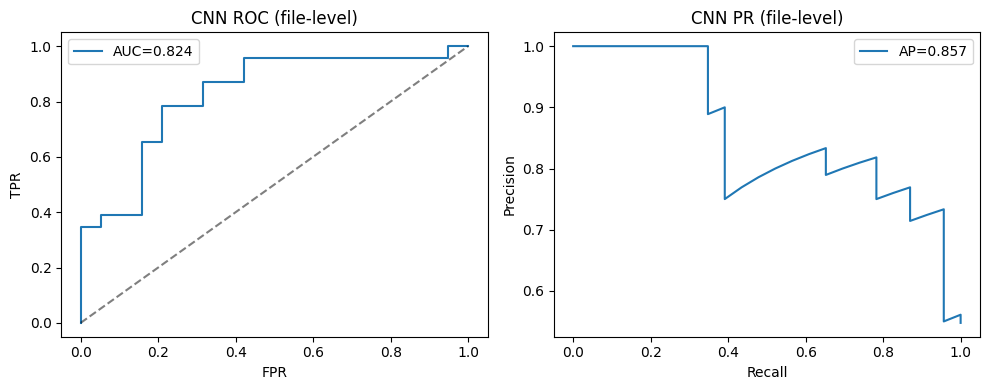


[RNN] Window-Level
Confusion matrix [[TN FP],[FN TP]]:
 [[6247 2835]
 [1997 8997]]
Precision: 0.7604 | Recall: 0.8184 | F1: 0.7883
Balanced Acc: 0.7531 | ROC-AUC: 0.8103 | PR-AUC: 0.8292

[RNN] File-Level
Confusion matrix [[TN FP],[FN TP]]:
 [[14  5]
 [ 3 20]]
Precision: 0.8000 | Recall: 0.8696 | F1: 0.8333
Balanced Acc: 0.8032 | ROC-AUC: 0.8330 | PR-AUC: 0.8605


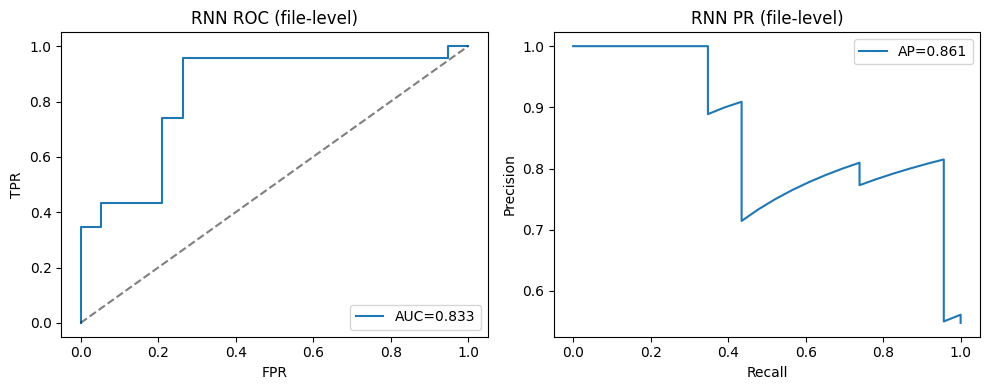

In [11]:
# Auswertung: Confusion Matrix, Precision, Recall, F1, Balanced Accuracy, ROC-AUC, PR-AUC
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

class _EvalDS(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.tensor(self.y[i], dtype=torch.long)

@torch.no_grad()
def _predict_probs(model, X, y, batch_size=256):
    ds = _EvalDS(X, y)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    all_probs, all_targets = [], []
    for xb, yb in dl:
        xb = xb.to(device)
        logits = model(xb)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(yb.numpy())
    probs = np.vstack(all_probs)             # (N, 2)
    y_true = np.concatenate(all_targets)     # (N,)
    y_pred = probs.argmax(1)                 # (N,)
    y_score = probs[:, 1]                    # (N,) – Score für positive Klasse (sch)
    return y_true, y_pred, y_score, probs

def _metrics_block(y_true, y_pred, y_score):
    # Binäre Kennzahlen (positive Klasse = 1 = sch)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    # AUCs robust berechnen
    try:
        roc_auc = roc_auc_score(y_true, y_score)
    except Exception:
        roc_auc = float("nan")
    try:
        pr_auc = average_precision_score(y_true, y_score)
    except Exception:
        pr_auc = float("nan")
    return dict(cm=cm, precision=prec, recall=rec, f1=f1, balanced_acc=bal_acc,
                roc_auc=roc_auc, pr_auc=pr_auc)

def evaluate_full(model, X, y, file_idx, name="Model", plot_curves=True):
    # Window-Level
    yw_true, yw_pred, yw_score, yw_probs = _predict_probs(model, X, y)
    win = _metrics_block(yw_true, yw_pred, yw_score)

    # File-Level (mittlere Wahrscheinlichkeit je Datei)
    files = np.unique(file_idx)
    pf, yf = [], []
    for fid in files:
        mask = (file_idx == fid)
        mean_prob = yw_probs[mask].mean(axis=0)  # (2,)
        pf.append(mean_prob[1])                  # Positiv-Score
        yf.append(yw_true[mask][0])              # alle Fenster haben dasselbe Label
    yf = np.array(yf, dtype=int)
    pf = np.array(pf, dtype=float)
    yfp = (pf >= 0.5).astype(int)
    fil = _metrics_block(yf, yfp, pf)

    # Ausgabe
    def _print_block(tag, m):
        print(f"\n[{name}] {tag}")
        print("Confusion matrix [[TN FP],[FN TP]]:\n", m['cm'])
        print(f"Precision: {m['precision']:.4f} | Recall: {m['recall']:.4f} | F1: {m['f1']:.4f}")
        print(f"Balanced Acc: {m['balanced_acc']:.4f} | ROC-AUC: {m['roc_auc']:.4f} | PR-AUC: {m['pr_auc']:.4f}")

    _print_block("Window-Level", win)
    _print_block("File-Level", fil)

    if plot_curves:
        # ROC + PR Kurven (File-Level empfohlen)
        try:
            fpr, tpr, _ = roc_curve(yf, pf)
            precs, recs, _ = precision_recall_curve(yf, pf)
            fig, axs = plt.subplots(1, 2, figsize=(10,4))
            axs[0].plot(fpr, tpr, label=f"AUC={fil['roc_auc']:.3f}")
            axs[0].plot([0,1], [0,1], 'k--', alpha=0.5)
            axs[0].set_title(f"{name} ROC (file-level)"); axs[0].set_xlabel("FPR"); axs[0].set_ylabel("TPR"); axs[0].legend()
            axs[1].plot(recs, precs, label=f"AP={fil['pr_auc']:.3f}")
            axs[1].set_title(f"{name} PR (file-level)"); axs[1].set_xlabel("Recall"); axs[1].set_ylabel("Precision"); axs[1].legend()
            plt.tight_layout(); plt.show()
        except Exception:
            pass

    return {"window": win, "file": fil}

# Beispiel-Aufruf (nach dem letzten Fold – Variablen aus dem CV-Loop sind weiter verfügbar):
# CNN
cnn_metrics_all = evaluate_full(cnn, X_val_s, y_val, val_file_idx, name="CNN", plot_curves=True)
# RNN
rnn_metrics_all = evaluate_full(rnn, X_val_s, y_val, val_file_idx, name="RNN", plot_curves=True)

In [12]:
# Einseitiger gepaarter t-Test: H1 = mean(RNN_file_acc - CNN_file_acc) > 0

import numpy as np
from scipy.stats import t as student_t  # t-Verteilung

# Verwende die bereits berechneten Arrays aus der CV:
# cnn_accs_files, rnn_accs_files (gleiche Folds, gleiche Reihenfolge)
diff = rnn_accs_files - cnn_accs_files
n = len(diff)
assert n >= 2, "Für einen gepaarten t-Test sind mindestens 2 Paare nötig."

mean_diff = float(diff.mean())
std_diff  = float(diff.std(ddof=1))
df = n - 1
eps = 1e-12
se = std_diff / (np.sqrt(n) + eps)
t_stat = mean_diff / (se + eps)

# Einseitiges p für H1: mean_diff > 0 (RNN > CNN)
p_one_sided = float(student_t.sf(t_stat, df))  # sf = 1 - cdf

# Optional: zweiseitig als Referenz
p_two_sided = float(min(1.0, p_one_sided * 2.0))

# Effektstärke (Cohen's dz) für gepaarte Designs
cohens_dz = mean_diff / (std_diff + eps)

print("Einseitiger gepaarter t-Test (File-Level Accuracies):")
print("H0: mean(RNN - CNN) <= 0")
print("H1: mean(RNN - CNN)  > 0  (RNN ist genauer als CNN)")
print(f"n = {n}, df = {df}")
print(f"Mean diff = {mean_diff:.4f}, Std diff = {std_diff:.4f}")
print(f"t = {t_stat:.4f}")
print(f"p_one_sided = {p_one_sided:.6f}  (einseitig)")
print(f"p_two_sided = {p_two_sided:.6f}  (Referenz)")
print(f"Cohen's dz = {cohens_dz:.4f}")

alpha = 0.05
if p_one_sided < alpha:
    print(f"Ergebnis: p < {alpha} → signifikant. Evidenz dafür, dass RNN genauer ist als CNN.")
else:
    print(f"Ergebnis: p ≥ {alpha} → nicht signifikant. Keine ausreichende Evidenz für RNN > CNN.")

Einseitiger gepaarter t-Test (File-Level Accuracies):
H0: mean(RNN - CNN) <= 0
H1: mean(RNN - CNN)  > 0  (RNN ist genauer als CNN)
n = 2, df = 1
Mean diff = 0.0595, Std diff = 0.0168
t = 5.0000
p_one_sided = 0.062833  (einseitig)
p_two_sided = 0.125666  (Referenz)
Cohen's dz = 3.5355
Ergebnis: p ≥ 0.05 → nicht signifikant. Keine ausreichende Evidenz für RNN > CNN.
